## Random Forest

![](https://velog.velcdn.com/images/newnew_daddy/post/eef1d250-a92a-4a5a-ac98-4273d8fcebc4/image.png)

- 대표적인 앙상블 학습 기법의 하나로, 여러개의 결정 트리(Decision Tree)를 결합하여 예측 성능을 향상시키는 방법.
- 분류와 회귀 모델에 모두 사용이 가능하며 특히 과적합 방지에 효과적이다.

#### 동작 원리

1. **훈련 데이터 생성**:
- 부트스트랩 샘플링을 통해 여러 개의 훈련 데이터셋을 생성합니다. 각 트리는 이 훈련 데이터셋 중 하나로 학습됩니다.

2. **트리 학습**:
- 각 트리는 특정 수의 특성들 중에서 무작위로 선택된 서브셋을 사용하여 데이터 분할을 수행합니다. 이렇게 생성된 트리는 서로 다른 부분을 학습하게 되어, 전체 모델의 다양성을 높입니다.

3. **예측 결합**:
- 분류 문제에서는 각 트리의 예측 결과를 투표로 결합하여 최종 클래스를 결정하고, 회귀 문제에서는 평균을 내어 최종 예측 값을 결정합니다.

<img src="https://velog.velcdn.com/images/newnew_daddy/post/567ba195-5c2d-429a-b760-55ba1047785d/image.png" width=60%>


In [1]:
import pandas as pd
from utils import evaluate_cls_model, plot_cm

# 생선 종(Species) 분류: 길이·무게 등 측정값 사용
df = pd.read_csv('./dataset/fish.csv')

df.head(), df.shape

(  Species  Weight  Length  Diagonal   Height   Width
 0   Bream   242.0    25.4      30.0  11.5200  4.0200
 1   Bream   290.0    26.3      31.2  12.4800  4.3056
 2   Bream   340.0    26.5      31.1  12.3778  4.6961
 3   Bream   363.0    29.0      33.5  12.7300  4.4555
 4   Bream   430.0    29.0      34.0  12.4440  5.1340,
 (159, 6))

In [2]:
input_cols = df.columns[1:]  # 첫 열은 보통 이름/식별자로 제외했다고 가정

X = df[input_cols].values
y = df['Species'].values

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

In [4]:
# 트리 단일 모델은 스케일 불변이나, 실습·다른 알고리즘과 통일하려면 표준화 가능
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

#### RandomForestClassifier 메소드의 주요 인자 설명

```python
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,      # 사용할 결정 트리의 개수. 기본값은 100. 트리 수가 많을수록 일반적으로 성능이 향상되지만 계산 비용도 증가함.
    criterion='gini',      # 분할 품질을 평가하는 기준. 'gini'는 지니 불순도, 'entropy'는 정보 이득을 사용. 기본값은 'gini'.
    max_depth=None,        # 각 트리의 최대 깊이. None으로 설정하면 트리의 모든 리프가 순수해질 때까지 또는 리프에 미니 샘플보다 적은 샘플이 있을 때까지 확장.
    min_samples_split=2,   # 내부 노드를 분할하는 데 필요한 최소 샘플 수. 너무 작은 값을 사용하면 과적합의 위험이 증가.
    min_samples_leaf=1,    # 리프 노드에 있어야 하는 최소 샘플 수. 과적합을 줄이기 위해 사용할 수 있음.
    min_weight_fraction_leaf=0.0, # 리프 노드의 최소 가중치 샘플 비율. 샘플의 가중치가 있는 경우 사용.
    max_features='auto',   # 각 분할에서 고려할 최대 특성 수. 'auto'는 분류 문제의 경우 특성 수의 제곱근을 의미. 'sqrt' 또는 'log2'도 사용할 수 있음.
    max_leaf_nodes=None,   # 리프 노드의 최대 수를 제한. 트리의 크기를 줄이는 데 유용.
    min_impurity_decrease=0.0, # 분할이 필요한 최소 순수도 감소. 이 값보다 큰 경우에만 분할이 이루어짐.
    bootstrap=True,        # 부트스트랩 샘플링을 사용할지 여부. True이면 무작위 샘플로 각 트리를 학습.
    oob_score=False,       # Out-of-bag 샘플(남는 샘플)을 사용하여 일반화 정확도를 추정할지 여부. True로 설정하면 모델이 적합된 후 oob_score_ 속성을 통해 OOB 점수를 사용할 수 있음.
    n_jobs=None,           # 작업을 수행할 병렬 작업 수. -1로 설정하면 가능한 모든 프로세서를 사용.
    random_state=None,     # 난수 시드. 동일한 데이터를 동일한 상태로 분할하려면 동일한 값을 사용.
    verbose=0,             # 학습 과정 중 출력할 정보의 양. 0이면 아무것도 출력하지 않음.
    class_weight=None,     # 클래스의 가중치를 지정. 'balanced'는 입력 데이터에서 자동으로 가중치를 계산하여 클래스 불균형을 보정.
)

```

In [5]:
from sklearn.ensemble import RandomForestClassifier

# 배깅 + 랜덤 특성 부분집합: 여러 트리의 투표/평균으로 과적합 완화
rf = RandomForestClassifier(
    n_estimators=10,   # 트리 개수
    max_depth=3,
    criterion='entropy',
    random_state=0,
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

=== RandomForest ===
Train Score: 0.7479
Test  Score: 0.6000

              precision    recall  f1-score   support

       Bream       0.89      1.00      0.94         8
      Parkki       0.00      0.00      0.00         3
       Perch       0.46      1.00      0.63        13
        Pike       1.00      0.29      0.44         7
       Roach       0.00      0.00      0.00         5
       Smelt       1.00      1.00      1.00         1
   Whitefish       0.00      0.00      0.00         3

    accuracy                           0.60        40
   macro avg       0.48      0.47      0.43        40
weighted avg       0.53      0.60      0.50        40



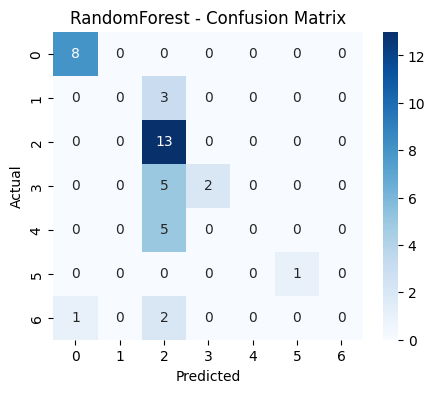

In [6]:
# 평가·시각화 (Classification_Models.ipynb utils)
y_pred = evaluate_cls_model(rf, X_train, X_test, y_train, y_test, "RandomForest")
plot_cm(y_test, y_pred, "RandomForest")

yt = pd.DataFrame(y_test, columns=["test"])
yp = pd.DataFrame(y_pred, columns=["pred"])
# pd.concat([yt, yp], axis=1)


In [7]:
# Train/Test 점수는 위 셀의 evaluate_cls_model 출력에 이미 포함됨


In [8]:
# 트리들에서 평균한 특성 중요도
pd.concat([pd.DataFrame(input_cols), pd.DataFrame(rf.feature_importances_)], axis=1)

,0,0
0,Weight,0.177246
1,Length,0.172504
2,Diagonal,0.158161
3,Height,0.344475
4,Width,0.147615


In [9]:
# estimators_: 학습된 각 결정트리 객체 리스트 (길이 = n_estimators)
len(rf.estimators_)

10

In [10]:
rf.classes_  # 학습에 등장한 클래스 라벨 순서 (plot_tree의 class_names와 대응)

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

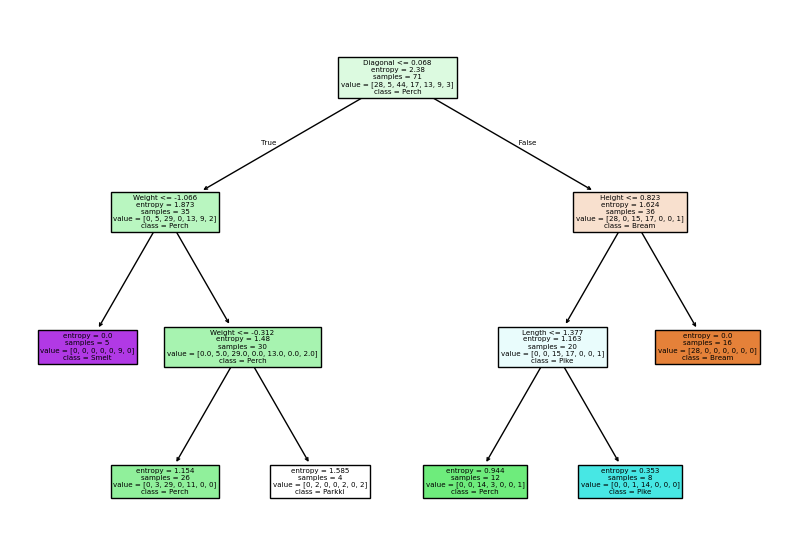

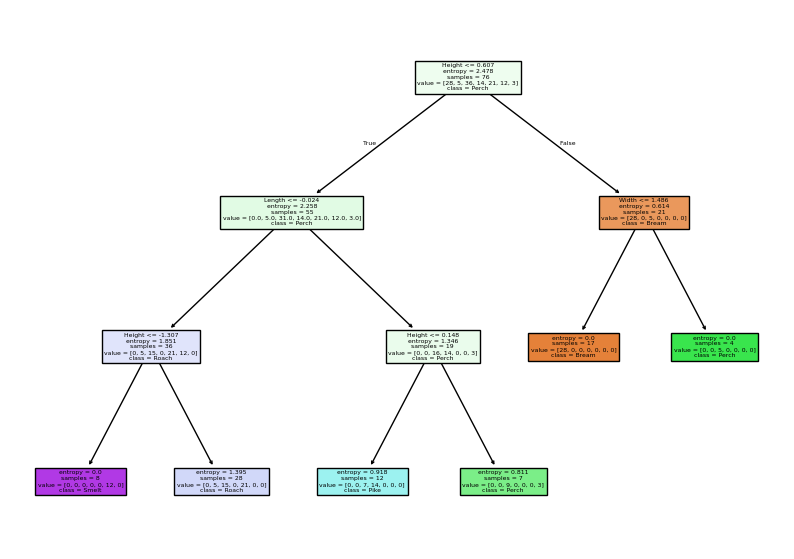

In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, export_text

# 앙상블 안의 개별 트리 2개만 예시로 시각화(각기 다른 부트스트랩·특성 샘플로 학습됨)
for i in range(2):
    plt.figure(figsize=(10, 7))
    plot_tree(
        rf.estimators_[i],
        filled=True,
        feature_names=input_cols,
        class_names=rf.classes_,
    )
    plt.show()

In [12]:
tree_text = export_text(rf.estimators_[0], max_depth=2, feature_names=input_cols)
print(tree_text[:5000])  # 첫 번째 트리 규칙 일부

|--- Diagonal <= 0.07
|   |--- Weight <= -1.07
|   |   |--- class: 5.0
|   |--- Weight >  -1.07
|   |   |--- Weight <= -0.31
|   |   |   |--- class: 2.0
|   |   |--- Weight >  -0.31
|   |   |   |--- class: 1.0
|--- Diagonal >  0.07
|   |--- Height <= 0.82
|   |   |--- Length <= 1.38
|   |   |   |--- class: 2.0
|   |   |--- Length >  1.38
|   |   |   |--- class: 3.0
|   |--- Height >  0.82
|   |   |--- class: 0.0

